Parcial 2 Computacional Dinámica

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sympy as sp
import math

In [2]:
#Punto 1



# Datos
k = 1500.0
L0 = 0.2
P = np.array([1.0, 1.0])
Q = np.array([0.8, 1.3])

# Vectores
rPQ = Q - P
L = np.linalg.norm(rPQ)
dL = L - L0

# Fuerza del resorte sobre Q (dirección hacia P)
F = -k * dL * (rPQ / L)

# Momento con respecto al origen (r × F)
rQ = Q
tau_z = np.cross(np.append(rQ, 0), np.append(F, 0))[2]

print(f"L = {L:.4f} m")
print(f"F = {np.linalg.norm(F):.2f} N,  Fx = {F[0]:.2f}, Fy = {F[1]:.2f}")
print(f"Momento (r × F) = {tau_z:.2f} N·m")


L = 0.3606 m
F = 240.83 N,  Fx = 133.59, Fy = -200.38
Momento (r × F) = -333.97 N·m


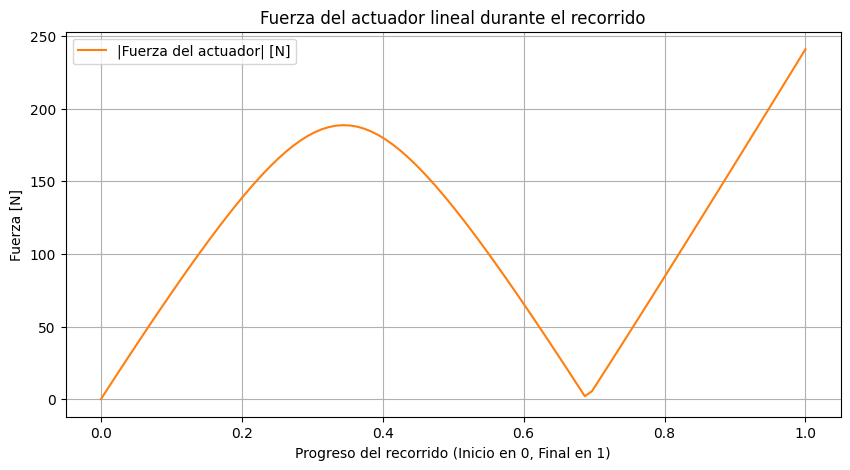

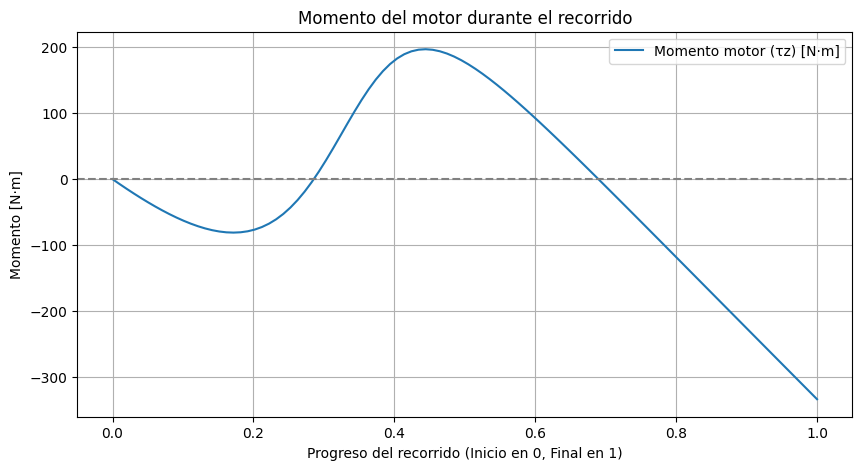

In [3]:


# Parámetros
k = 1500.0       # N/m
L0 = 0.2         # m
P = np.array([1.0, 1.0])
Q_i = np.array([1.0, 0.8])
Q_f = np.array([0.8, 1.3])

# Trayectoria lineal
t_vals = np.linspace(0, 1, 100)
Q_vals = np.outer(1 - t_vals, Q_i) + np.outer(t_vals, Q_f)

# Listas para guardar resultados
F_vals = []
Tau_vals = []

for Q in Q_vals:
    rPQ = Q - P
    L = np.linalg.norm(rPQ)
    dL = L - L0
    F = -k * dL * (rPQ / L)              # Fuerza del resorte sobre Q
    tau_z = np.cross(np.append(Q, 0), np.append(F, 0))[2]  # Momento r x F
    F_vals.append(np.linalg.norm(F))
    Tau_vals.append(tau_z)

# --- Gráficas ---
plt.figure(figsize=(10, 5))
plt.plot(t_vals, F_vals, label='|Fuerza del actuador| [N]', color='C1')
plt.xlabel('Progreso del recorrido (Inicio en 0, Final en 1)')
plt.ylabel('Fuerza [N]')
plt.title('Fuerza del actuador lineal durante el recorrido')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(t_vals, Tau_vals, label='Momento motor (τz) [N·m]', color='C0')
plt.xlabel('Progreso del recorrido (Inicio en 0, Final en 1)')
plt.ylabel('Momento [N·m]')
plt.title('Momento del motor durante el recorrido')
plt.axhline(0, color='gray', linestyle='--')
plt.grid(True)
plt.legend()
plt.show()


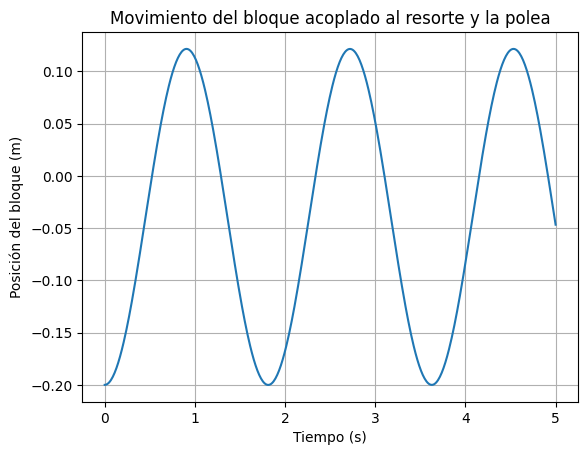

In [ ]:
#Punto 2


# Datos 
# Punto 2 (versión con variables renombradas)

# Datos 
masa_bloque = 0.5
masa_polea = 1.5
const_resorte = 15
radio_polea = 0.12
inercia_polea = 0.5 * masa_polea * radio_polea**2

def dinamica_sistema(tiempo, estado):
    desplazamiento, velocidad = estado
    aceleracion = (-const_resorte * desplazamiento - masa_bloque * 9.81 * radio_polea) / (masa_bloque + inercia_polea / radio_polea**2)
    return [velocidad, aceleracion]

# Condiciones iniciales (invertido)
despl_inicial = -0.2   # antes era +0.2
vel_inicial = 0.0
estado_inicial = [despl_inicial, vel_inicial]

# Rangos
intervalo_tiempo = (0, 5)
vector_tiempo = np.linspace(*intervalo_tiempo, 500)
solucion = solve_ivp(dinamica_sistema, intervalo_tiempo, estado_inicial, t_eval=vector_tiempo)

# Gráfica
plt.plot(solucion.t, solucion.y[0])
plt.xlabel("Tiempo (s)")
plt.ylabel("Posición del bloque (m)")
plt.title("Movimiento del bloque acoplado al resorte y la polea")
plt.grid()
plt.show()



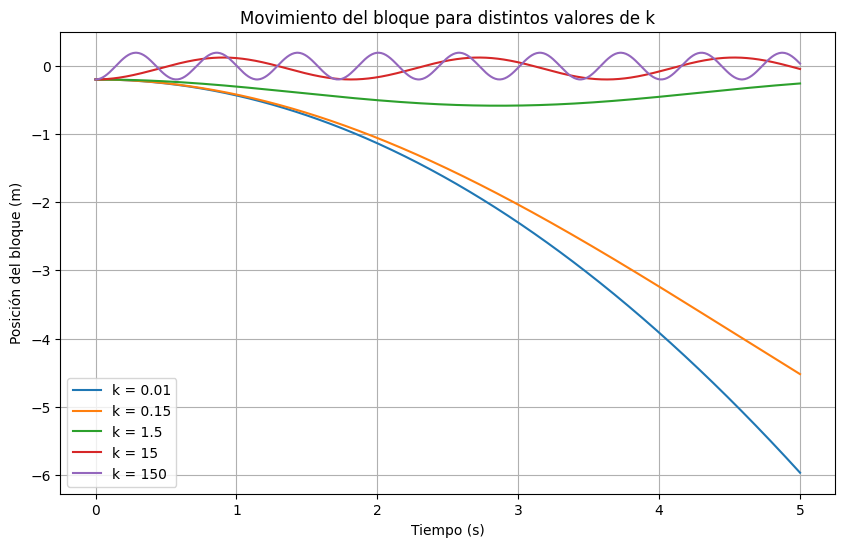

In [5]:
#Avanzado punto 2: analizar distintos k


# Parámetros constantes
masa_bloque = 0.5
masa_polea = 1.5
radio_polea = 0.12
gravedad = 9.81
inercia_polea = 0.5 * masa_polea * radio_polea**2

# Conjunto de constantes elásticas a analizar
constantes_resorte = [0.01, 0.15, 1.5, 15, 150]

def dinamica_sistema(tiempo, estado, constante_k):
    desplazamiento, velocidad = estado
    aceleracion = (-constante_k * desplazamiento - masa_bloque * gravedad * radio_polea) / (masa_bloque + inercia_polea / radio_polea**2)
    return [velocidad, aceleracion]

# Condiciones iniciales
despl_inicial = -0.2
vel_inicial = 0.0
estado_inicial = [despl_inicial, vel_inicial]

# Tiempo
intervalo_tiempo = (0, 5)
vector_tiempo = np.linspace(*intervalo_tiempo, 600)

plt.figure(figsize=(10, 6))

# Simular cada constante de resorte
for constante_k in constantes_resorte:
    solucion = solve_ivp(dinamica_sistema, intervalo_tiempo, estado_inicial, t_eval=vector_tiempo, args=(constante_k,))
    plt.plot(solucion.t, solucion.y[0], label=f"k = {constante_k}")

plt.xlabel("Tiempo (s)")
plt.ylabel("Posición del bloque (m)")
plt.title("Movimiento del bloque para distintos valores de k")
plt.grid()
plt.legend()
plt.show()


En este caso nos podemos dar cuenta que a medida que el K aumenta el resorte oscila a mayor frecuencia, y hay un punto, en este caso por debajo de 1.5N/m donde el k no es suficientemente grande como para devolver la masa y por eso solo sigue cayendo hasta que en algun momento el resorte se rompa. Tambien podemos ver como toda la gráfica sigue este comporteamiento; todase empezando desde -0.2.

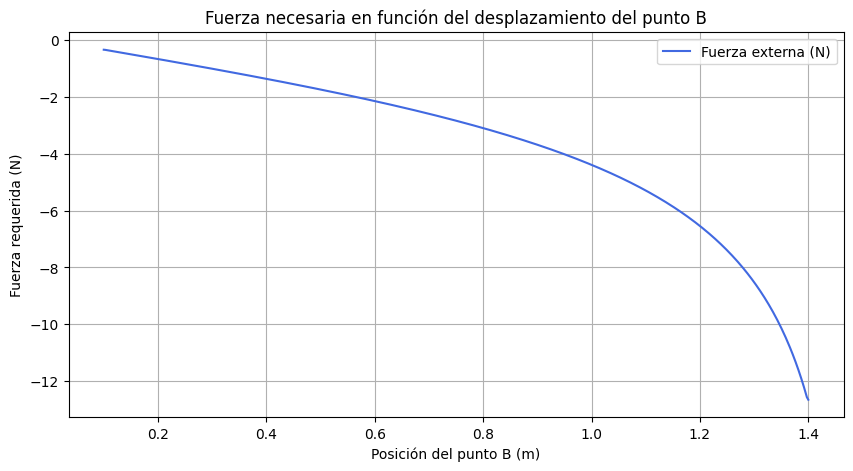

In [6]:
# Punto 3 

# Parámetros Inicialeas
masa_barra = 1.0         
gravedad = 9.81          
longitud_barra = 1.5     

# Rango de desplazamiento del punto móvil B
posiciones_B = np.linspace(0.1, 1.4, 500)
fuerza_aplicada = []
energia_potencial = []

# Cálculo de energía potencial del centro de masa
for posicion in posiciones_B:
    x_b = posicion
    y_b = 0.0
    x_a = 0.0
    y_a = np.sqrt(longitud_barra**2 - (x_b - x_a)**2) 
    
    # centro de masa
    x_cm = (x_a + x_b) / 2
    y_cm = (y_a + y_b) / 2

    # Energía potencial
    energia_cm = masa_barra * gravedad * y_cm
    energia_potencial.append(energia_cm)

# Cálculo de la derivada de la energía (fuerza externa requerida)
energia_potencial = np.array(energia_potencial)
derivada_Ep = np.gradient(energia_potencial, posiciones_B)
fuerza_aplicada = derivada_Ep

# Representación gráfica
plt.figure(figsize=(10, 5))
plt.plot(posiciones_B, fuerza_aplicada, label='Fuerza externa (N)', color='royalblue')
plt.title("Fuerza necesaria en función del desplazamiento del punto B")
plt.xlabel("Posición del punto B (m)")
plt.ylabel("Fuerza requerida (N)")
plt.grid(True)
plt.legend()
plt.show()


In [7]:
#4 no se si este bien lo hice a la carrera paro ojala valga para algo :)


m = 43.0
g = 9.81
r = 1.4 + 0.22

t = sp.Symbol("t", real=True)

# theta(t)
theta = 1.5*sp.exp(-t) - 1 - t + sp.pi/2

# derivadas
omega = sp.diff(theta, t)
alpha = sp.diff(omega, t)

# evaluación en t = 0
theta0 = float(theta.subs(t, 0))
omega0 = float(omega.subs(t, 0))
alpha0 = float(alpha.subs(t, 0))

# aceleraciones lineales
A_t = alpha0 * r
A_c = omega0**2 * r

# ángulo para el peso
phi = theta0 - math.pi/2

Wx = -m * g * math.sin(phi)
Wy = -m * g * math.cos(phi)

# tensiones con signos corregidos
Tx = (m*A_t - Wx)
Ty = -(m*A_c + Wy)

T_total = math.hypot(Tx, Ty)

# resultados
print(f"theta0 = {math.degrees(theta0):.3f}°")
print(f"omega0 = {omega0:.4f} rad/s")
print(f"alpha0 = {alpha0:.4f} rad/s²")
print()
print(f"A_t = {A_t:.4f} m/s²   (m·A_t = {m*A_t:.2f} N)")
print(f"A_c = {A_c:.4f} m/s²   (m·A_c = {m*A_c:.2f} N)")
print()
print(f"Wx = {Wx:.3f} N")
print(f"Wy = {Wy:.3f} N")
print()
print(f"Tx = {Tx:.3f} N")
print(f"Ty = {Ty:.3f} N")
print(f"T_total = {T_total:.3f} N")








theta0 = 118.648°
omega0 = -2.5000 rad/s
alpha0 = 1.5000 rad/s²

A_t = 2.4300 m/s²   (m·A_t = 104.49 N)
A_c = 10.1250 m/s²   (m·A_c = 435.38 N)

Wx = -202.236 N
Wy = -370.191 N

Tx = 306.726 N
Ty = -65.184 N
T_total = 313.576 N
